# Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from IPython.display import display

# Load the dataset

In [2]:
df = pd.read_csv(r"C:\Users\Visla\Downloads\Files\Project_file\Project-7\Banking-Management-System-Flask\Machine Learning\fraud_detection\transactions_ml.csv")

print("Dataset loaded successfully.")
print("Shape:", df.shape)

display(df.head())

Dataset loaded successfully.
Shape: (10000, 18)


,transaction_id,transaction_reference,account_id,transaction_type,amount,transaction_date,transaction_status,remarks,hour,day_of_week,day_of_month,month,is_weekend,account_average_amount,account_std_amount,account_transaction_count,amount_deviation,is_anomaly
0,1,TXN00000001,328,Deposit,18689.78,2025-07-20 06:29:00,Success,Normal transaction,6,6,20,7,1,18841.39,9168.18,19,0.0165,0
1,2,TXN00000002,72,UPI,15066.13,2025-03-05 07:21:00,Success,Normal transaction,7,2,5,3,0,7052.21,4827.00,23,1.6602,0
2,3,TXN00000003,17,Deposit,13415.35,2025-06-09 04:58:00,Success,Normal transaction,4,0,9,6,0,8891.42,4591.88,15,0.9852,0
3,4,TXN00000004,309,Deposit,14549.23,2025-05-25 18:56:00,Success,Normal transaction,18,6,25,5,1,24758.81,26535.48,23,0.3848,0
4,5,TXN00000005,360,Transfer,8906.96,2025-06-10 12:28:00,Success,Normal transaction,12,1,10,6,0,16741.99,9028.06,21,0.8679,0


In [3]:
print("Columns in dataset:")
print()

for i, column in enumerate(df.columns, start=1):
    print(f"{i}. {column}")

Columns in dataset:

1. transaction_id
2. transaction_reference
3. account_id
4. transaction_type
5. amount
6. transaction_date
7. transaction_status
8. remarks
9. hour
10. day_of_week
11. day_of_month
12. month
13. is_weekend
14. account_average_amount
15. account_std_amount
16. account_transaction_count
17. amount_deviation
18. is_anomaly


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   transaction_id             10000 non-null  int64  
 1   transaction_reference      10000 non-null  object 
 2   account_id                 10000 non-null  int64  
 3   transaction_type           10000 non-null  object 
 4   amount                     10000 non-null  float64
 5   transaction_date           10000 non-null  object 
 6   transaction_status         10000 non-null  object 
 7   remarks                    10000 non-null  object 
 8   hour                       10000 non-null  int64  
 9   day_of_week                10000 non-null  int64  
 10  day_of_month               10000 non-null  int64  
 11  month                      10000 non-null  int64  
 12  is_weekend                 10000 non-null  int64  
 13  account_average_amount     10000 non-null  floa

# Missing values

In [5]:
missing_values = df.isnull().sum()

print("Missing values:")
display(
    missing_values[
        missing_values > 0
    ]
)

Missing values:


Series([], dtype: int64)

# Duplicate transactions

In [6]:
duplicate_count = df.duplicated().sum()

print("Duplicate rows:", duplicate_count)

Duplicate rows: 0


# Statistical summary

In [7]:
display(
    df.describe()
)

,transaction_id,account_id,amount,hour,day_of_week,day_of_month,month,is_weekend,account_average_amount,account_std_amount,account_transaction_count,amount_deviation,is_anomaly
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,250.379100,17007.436263,11.329700,3.001000,15.731400,6.525300,0.285000,14912.765291,8637.205258,21.017000,1.020973,0.030000
std,2886.89568,143.948835,28735.731834,6.997035,1.996597,8.819469,3.448906,0.451437,8972.247827,6143.531651,4.556949,2.833003,0.170596
min,1.00000,1.000000,180.210000,0.000000,0.000000,1.000000,1.000000,0.000000,718.770000,360.690000,9.000000,0.000100,0.000000
25%,2500.75000,126.000000,5343.820000,5.000000,1.000000,8.000000,4.000000,0.000000,6951.390000,3679.540000,18.000000,0.323400,0.000000
50%,5000.50000,249.000000,11657.935000,11.000000,3.000000,16.000000,7.000000,0.000000,15090.410000,7843.860000,21.000000,0.646150,0.000000
75%,7500.25000,375.000000,20762.715000,17.000000,5.000000,23.000000,10.000000,1.000000,22400.120000,12232.570000,24.000000,1.022325,0.000000
max,10000.00000,500.000000,920530.970000,23.000000,6.000000,31.000000,12.000000,1.000000,40855.080000,41172.700000,35.000000,65.677500,1.000000


# Transaction type distribution

In [8]:
transaction_counts = (
    df["transaction_type"]
    .value_counts()
)

display(transaction_counts)

transaction_type
Deposit       2957
Withdrawal    2087
UPI           1503
Transfer      1472
NEFT           827
IMPS           663
RTGS           491
Name: count, dtype: int64

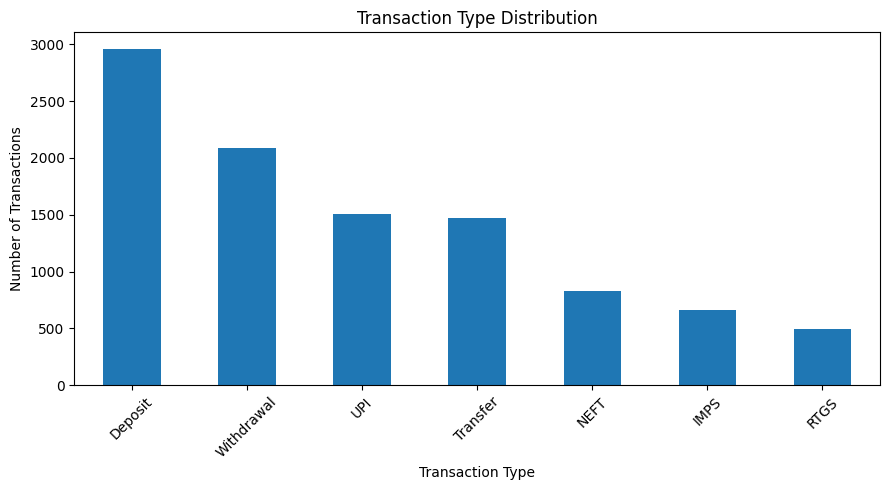

In [9]:
plt.figure(figsize=(9, 5))

transaction_counts.plot(
    kind="bar"
)

plt.title("Transaction Type Distribution")
plt.xlabel("Transaction Type")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [10]:
status_counts = (
    df["transaction_status"]
    .value_counts()
)

display(status_counts)

transaction_status
Success    9190
Pending     539
Failed      271
Name: count, dtype: int64

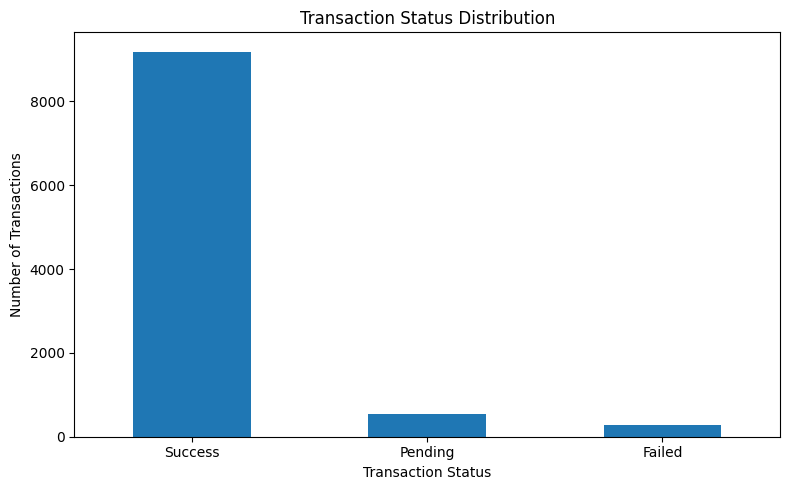

In [11]:
plt.figure(figsize=(8, 5))

status_counts.plot(
    kind="bar"
)

plt.title("Transaction Status Distribution")
plt.xlabel("Transaction Status")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Normal vs anomalous transactions

In [12]:
anomaly_counts = (
    df["is_anomaly"]
    .value_counts()
    .sort_index()
)

print("Anomaly distribution:")

display(anomaly_counts)

Anomaly distribution:


is_anomaly
0    9700
1     300
Name: count, dtype: int64

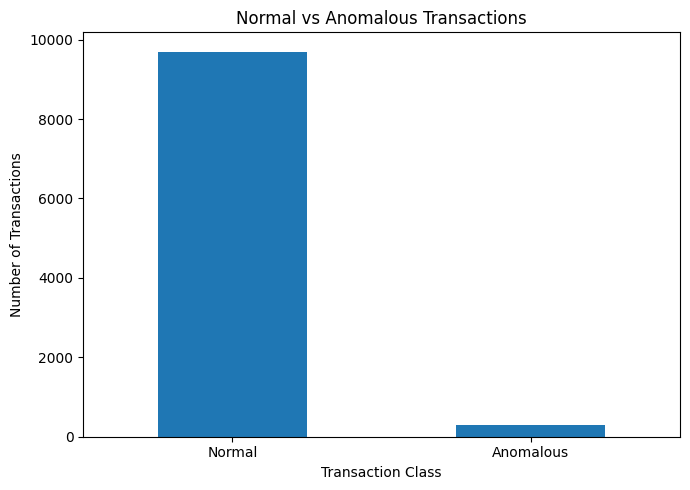

In [13]:
plt.figure(figsize=(7, 5))

anomaly_counts.plot(
    kind="bar"
)

plt.title("Normal vs Anomalous Transactions")
plt.xlabel("Transaction Class")
plt.ylabel("Number of Transactions")
plt.xticks(
    [0, 1],
    ["Normal", "Anomalous"],
    rotation=0
)

plt.tight_layout()
plt.show()

# Transaction amount distribution

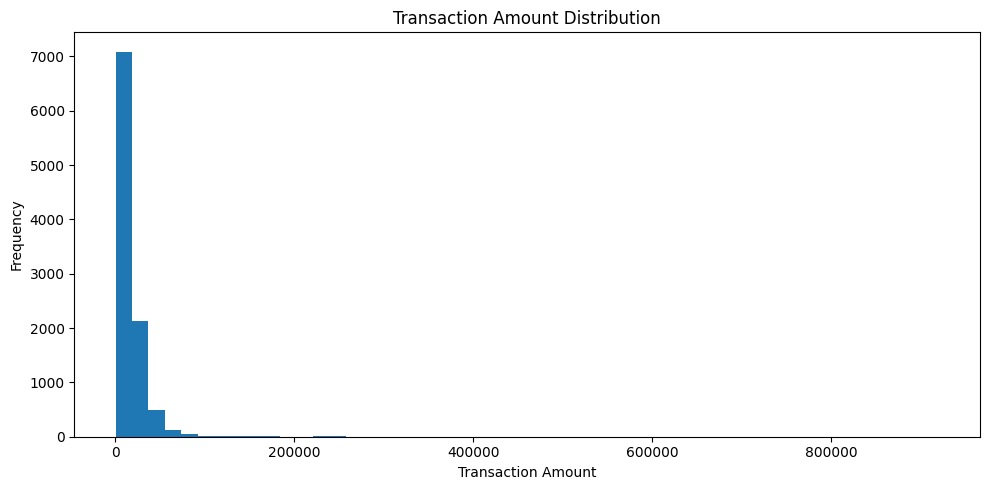

In [14]:
plt.figure(figsize=(10, 5))

plt.hist(
    df["amount"],
    bins=50
)

plt.title("Transaction Amount Distribution")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

# Amount by anomaly status

In [15]:
normal_amounts = df.loc[
    df["is_anomaly"] == 0,
    "amount"
]

anomaly_amounts = df.loc[
    df["is_anomaly"] == 1,
    "amount"
]

print(
    "Normal transaction average:",
    round(normal_amounts.mean(), 2)
)

print(
    "Anomalous transaction average:",
    round(anomaly_amounts.mean(), 2)
)

Normal transaction average: 14903.84
Anomalous transaction average: 85023.76


# Unusual transaction hours

In [16]:
hour_counts = (
    df["hour"]
    .value_counts()
    .sort_index()
)

display(hour_counts)

hour
0     468
1     437
2     448
3     481
4     407
5     390
6     397
7     414
8     395
9     432
10    419
11    423
12    395
13    393
14    407
15    417
16    386
17    407
18    422
19    392
20    435
21    423
22    428
23    384
Name: count, dtype: int64

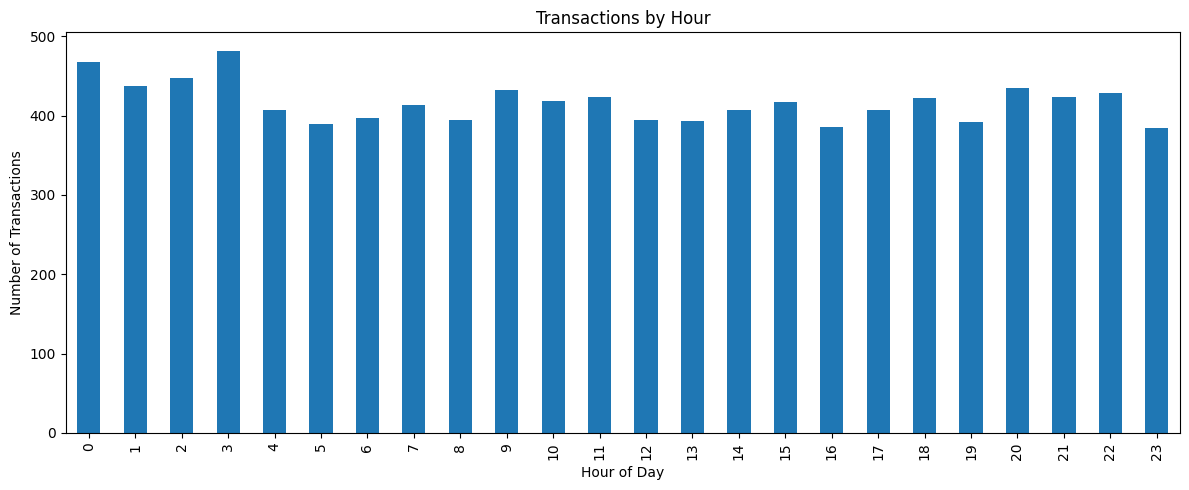

In [17]:
plt.figure(figsize=(12, 5))

hour_counts.plot(
    kind="bar"
)

plt.title("Transactions by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Transactions")

plt.tight_layout()
plt.show()

# Anomaly rate

In [18]:
anomaly_rate = (
    df["is_anomaly"].mean()
    * 100
)

print(
    f"Anomaly rate: {anomaly_rate:.2f}%"
)

Anomaly rate: 3.00%


# Most important comparison

In [19]:
summary = df.groupby(
    "is_anomaly"
)[
    [
        "amount",
        "hour",
        "account_average_amount",
        "account_std_amount",
        "account_transaction_count",
        "amount_deviation"
    ]
].mean()

summary.index = [
    "Normal",
    "Anomalous"
]

display(
    summary.round(2)
)

,amount,hour,account_average_amount,account_std_amount,account_transaction_count,amount_deviation
Normal,14903.84,11.47,14907.92,8637.42,21.02,0.75
Anomalous,85023.76,6.83,15069.55,8630.14,20.83,9.63


# Correlation analysis

In [20]:
numeric_columns = [
    "amount",
    "hour",
    "day_of_week",
    "day_of_month",
    "month",
    "is_weekend",
    "account_average_amount",
    "account_std_amount",
    "account_transaction_count",
    "amount_deviation",
    "is_anomaly"
]

correlation = (
    df[numeric_columns]
    .corr()
)

display(
    correlation["is_anomaly"]
    .sort_values(
        ascending=False
    )
)

is_anomaly                   1.000000
amount_deviation             0.534403
amount                       0.416282
is_weekend                   0.012337
day_of_week                  0.007546
account_average_amount       0.003073
account_std_amount          -0.000202
day_of_month                -0.001424
account_transaction_count   -0.007217
month                       -0.028487
hour                        -0.113101
Name: is_anomaly, dtype: float64

# Feature Engineering + Model Preparation

In [21]:
# Convert transaction_date to datetime

df["transaction_date"] = pd.to_datetime(
    df["transaction_date"]
)

print(df["transaction_date"].dtype)

datetime64[ns]


In [22]:
# Select features for ML

features = [
    "amount",
    "hour",
    "day_of_week",
    "day_of_month",
    "month",
    "is_weekend",
    "account_average_amount",
    "account_std_amount",
    "account_transaction_count",
    "amount_deviation"
]

X = df[features].copy()

y = df["is_anomaly"].copy()

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

display(X.head())

Feature shape: (10000, 10)
Target shape: (10000,)


,amount,hour,day_of_week,day_of_month,month,is_weekend,account_average_amount,account_std_amount,account_transaction_count,amount_deviation
0,18689.78,6,6,20,7,1,18841.39,9168.18,19,0.0165
1,15066.13,7,2,5,3,0,7052.21,4827.00,23,1.6602
2,13415.35,4,0,9,6,0,8891.42,4591.88,15,0.9852
3,14549.23,18,6,25,5,1,24758.81,26535.48,23,0.3848
4,8906.96,12,1,10,6,0,16741.99,9028.06,21,0.8679


In [23]:
print("Missing values:")
print(X.isnull().sum())

print("\nInfinite values:")
print(np.isinf(X).sum())

Missing values:
amount                       0
hour                         0
day_of_week                  0
day_of_month                 0
month                        0
is_weekend                   0
account_average_amount       0
account_std_amount           0
account_transaction_count    0
amount_deviation             0
dtype: int64

Infinite values:
amount                       0
hour                         0
day_of_week                  0
day_of_month                 0
month                        0
is_weekend                   0
account_average_amount       0
account_std_amount           0
account_transaction_count    0
amount_deviation             0
dtype: int64


# Scale the features

In [24]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(
    X_scaled,
    columns=features
)

display(X_scaled.head())

,amount,hour,day_of_week,day_of_month,month,is_weekend,account_average_amount,account_std_amount,account_transaction_count,amount_deviation
0,0.058548,-0.761746,1.502131,0.484022,0.137645,1.583910,0.437886,0.086433,-0.442643,-0.354579
1,-0.067561,-0.618822,-0.501378,-1.216846,-1.022201,-0.631349,-0.876140,-0.620229,0.435181,0.225647
2,-0.125010,-1.047596,-1.503133,-0.763281,-0.152317,-0.631349,-0.671141,-0.658502,-1.320467,-0.012628
3,-0.085550,0.953352,1.502131,1.050978,-0.442278,1.583910,1.097444,2.913498,0.435181,-0.224569
4,-0.281910,0.095803,-1.002256,-0.649890,-0.152317,-0.631349,0.203886,0.063624,-0.003731,-0.054035


In [25]:
print("Mean of scaled features:")
display(X_scaled.mean().round(3))

print("\nStandard deviation of scaled features:")
display(X_scaled.std().round(3))

Mean of scaled features:


amount                       0.0
hour                        -0.0
day_of_week                  0.0
day_of_month                -0.0
month                        0.0
is_weekend                   0.0
account_average_amount       0.0
account_std_amount          -0.0
account_transaction_count    0.0
amount_deviation             0.0
dtype: float64


Standard deviation of scaled features:


amount                       1.0
hour                         1.0
day_of_week                  1.0
day_of_month                 1.0
month                        1.0
is_weekend                   1.0
account_average_amount       1.0
account_std_amount           1.0
account_transaction_count    1.0
amount_deviation             1.0
dtype: float64

# Isolation Forest Anomaly Detection


In [26]:
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, confusion_matrix

model = IsolationForest(
    n_estimators=200,
    contamination=0.03,
    random_state=42,
    n_jobs=-1
)

model.fit(X_scaled)

print("Isolation Forest model trained successfully.")

Isolation Forest model trained successfully.


# Generate predictions

Isolation Forest returns:

1 → normal

-1 → anomaly

We'll convert that into your project format:

0 → normal

1 → anomaly

In [27]:
predictions = model.predict(X_scaled)

df["ml_prediction"] = np.where(
    predictions == -1,
    1,
    0
)

print("Predictions generated successfully.")

Predictions generated successfully.


In [28]:
print("ML Prediction Distribution:")

display(
    df["ml_prediction"]
    .value_counts()
    .sort_index()
)

ML Prediction Distribution:


ml_prediction
0    9700
1     300
Name: count, dtype: int64

# Compare actual vs ML prediction

In [29]:
comparison = pd.crosstab(
    df["is_anomaly"],
    df["ml_prediction"],
    rownames=["Actual"],
    colnames=["ML Prediction"]
)

display(comparison)

ML Prediction,0,1
Actual,,
0,9513,187
1,187,113


# Classification report

In [30]:
print(
    classification_report(
        df["is_anomaly"],
        df["ml_prediction"],
        target_names=["Normal", "Anomalous"]
    )
)

              precision    recall  f1-score   support

      Normal       0.98      0.98      0.98      9700
   Anomalous       0.38      0.38      0.38       300

    accuracy                           0.96     10000
   macro avg       0.68      0.68      0.68     10000
weighted avg       0.96      0.96      0.96     10000



# Confusion matrix

In [31]:
cm = confusion_matrix(
    df["is_anomaly"],
    df["ml_prediction"]
)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[9513  187]
 [ 187  113]]


# Isolation Forest Score Analysis

In [32]:
# Get anomaly scores

df["anomaly_score"] = model.decision_function(X_scaled)

display(
    df[
        [
            "amount",
            "amount_deviation",
            "hour",
            "account_average_amount",
            "anomaly_score",
            "is_anomaly",
            "ml_prediction"
        ]
    ].head(10)
)

,amount,amount_deviation,hour,account_average_amount,anomaly_score,is_anomaly,ml_prediction
0,18689.78,0.0165,6,18841.39,0.094115,0,0
1,15066.13,1.6602,7,7052.21,0.108224,0,0
2,13415.35,0.9852,4,8891.42,0.109112,0,0
3,14549.23,0.3848,18,24758.81,0.034223,0,0
4,8906.96,0.8679,12,16741.99,0.152772,0,0
5,16622.97,0.0007,17,16629.69,0.058915,0,0
6,7629.57,1.0674,18,16371.67,0.121517,0,0
7,20807.37,2.0199,2,9078.27,0.059706,0,0
8,16846.64,2.0608,11,8354.85,0.100350,0,0
9,11240.14,0.8501,13,17007.59,0.076103,0,0


In [33]:
# Compare anomaly scores for actual normal and anomalous transactions

score_summary = df.groupby("is_anomaly")["anomaly_score"].agg(
    ["mean", "min", "max", "std"]
)

display(score_summary)

,mean,min,max,std
is_anomaly,,,,
0,0.083978,-0.097853,0.157235,0.035245
1,0.022192,-0.117566,0.134706,0.068675


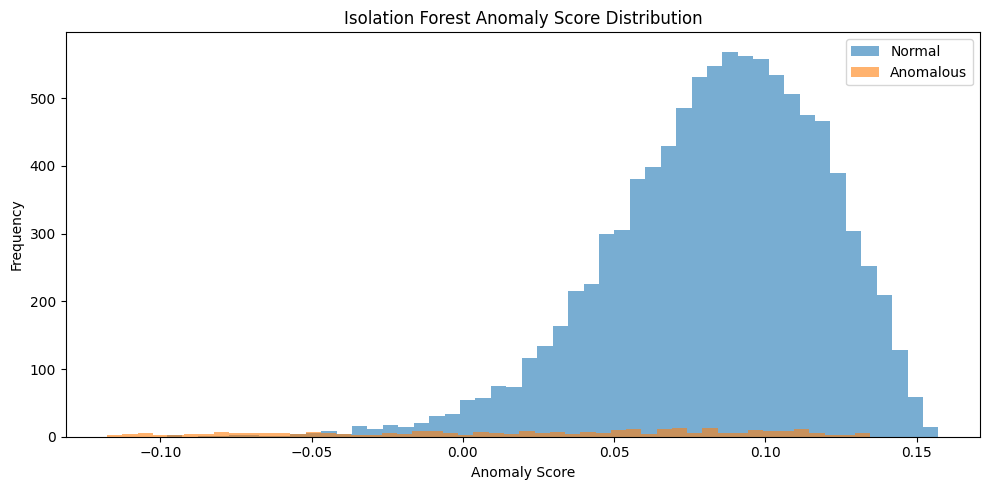

In [34]:
plt.figure(figsize=(10, 5))

plt.hist(
    df.loc[df["is_anomaly"] == 0, "anomaly_score"],
    bins=50,
    alpha=0.6,
    label="Normal"
)

plt.hist(
    df.loc[df["is_anomaly"] == 1, "anomaly_score"],
    bins=50,
    alpha=0.6,
    label="Anomalous"
)

plt.title("Isolation Forest Anomaly Score Distribution")
plt.xlabel("Anomaly Score")
plt.ylabel("Frequency")
plt.legend()

plt.tight_layout()
plt.show()

# Feature Engineering


# Improved Feature Engineering

In [35]:
# Create additional transaction behavior features

df["amount_to_average_ratio"] = (
    df["amount"] /
    (df["account_average_amount"] + 1)
)

df["amount_z_score"] = (
    (df["amount"] - df["account_average_amount"]) /
    (df["account_std_amount"] + 1)
)

# Time-based cyclic features
df["hour_sin"] = np.sin(
    2 * np.pi * df["hour"] / 24
)

df["hour_cos"] = np.cos(
    2 * np.pi * df["hour"] / 24
)

print("New features created successfully.")

display(
    df[
        [
            "amount",
            "account_average_amount",
            "account_std_amount",
            "amount_deviation",
            "amount_to_average_ratio",
            "amount_z_score",
            "hour_sin",
            "hour_cos"
        ]
    ].head()
)

New features created successfully.


,amount,account_average_amount,account_std_amount,amount_deviation,amount_to_average_ratio,amount_z_score,hour_sin,hour_cos
0,18689.78,18841.39,9168.18,0.0165,0.991901,-0.016535,1.000000e+00,6.123234e-17
1,15066.13,7052.21,4827.00,1.6602,2.136067,1.659884,9.659258e-01,-2.588190e-01
2,13415.35,8891.42,4591.88,0.9852,1.508628,0.984988,8.660254e-01,5.000000e-01
3,14549.23,24758.81,26535.48,0.3848,0.587615,-0.384738,-1.000000e+00,-1.836970e-16
4,8906.96,16741.99,9028.06,0.8679,0.531981,-0.867757,1.224647e-16,-1.000000e+00


# Encode transaction type and status

In [36]:
from sklearn.preprocessing import OneHotEncoder

categorical_features = [
    "transaction_type",
    "transaction_status"
]

encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

X_categorical = encoder.fit_transform(
    df[categorical_features]
)

categorical_names = encoder.get_feature_names_out(
    categorical_features
)

X_categorical = pd.DataFrame(
    X_categorical,
    columns=categorical_names,
    index=df.index
)

display(X_categorical.head())

,transaction_type_Deposit,transaction_type_IMPS,transaction_type_NEFT,transaction_type_RTGS,transaction_type_Transfer,transaction_type_UPI,transaction_type_Withdrawal,transaction_status_Failed,transaction_status_Pending,transaction_status_Success
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0


# Build improved numerical features

In [37]:
numerical_features = [
    "amount",
    "hour",
    "day_of_week",
    "day_of_month",
    "month",
    "is_weekend",
    "account_average_amount",
    "account_std_amount",
    "account_transaction_count",
    "amount_deviation",
    "amount_to_average_ratio",
    "amount_z_score",
    "hour_sin",
    "hour_cos"
]

X_numerical = df[numerical_features].copy()

print("Numerical feature shape:")
print(X_numerical.shape)

Numerical feature shape:
(10000, 14)


# Scale numerical features

In [38]:
scaler_improved = StandardScaler()

X_numerical_scaled = scaler_improved.fit_transform(
    X_numerical
)

X_numerical_scaled = pd.DataFrame(
    X_numerical_scaled,
    columns=numerical_features,
    index=df.index
)

# Combine everything

In [39]:
X_improved = pd.concat(
    [
        X_numerical_scaled,
        X_categorical
    ],
    axis=1
)

print("Improved feature matrix shape:")
print(X_improved.shape)

display(X_improved.head())

Improved feature matrix shape:
(10000, 24)


,amount,hour,day_of_week,day_of_month,month,is_weekend,account_average_amount,account_std_amount,account_transaction_count,amount_deviation,...,transaction_type_Deposit,transaction_type_IMPS,transaction_type_NEFT,transaction_type_RTGS,transaction_type_Transfer,transaction_type_UPI,transaction_type_Withdrawal,transaction_status_Failed,transaction_status_Pending,transaction_status_Success
0,0.058548,-0.761746,1.502131,0.484022,0.137645,1.583910,0.437886,0.086433,-0.442643,-0.354579,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,-0.067561,-0.618822,-0.501378,-1.216846,-1.022201,-0.631349,-0.876140,-0.620229,0.435181,0.225647,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
2,-0.125010,-1.047596,-1.503133,-0.763281,-0.152317,-0.631349,-0.671141,-0.658502,-1.320467,-0.012628,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,-0.085550,0.953352,1.502131,1.050978,-0.442278,1.583910,1.097444,2.913498,0.435181,-0.224569,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,-0.281910,0.095803,-1.002256,-0.649890,-0.152317,-0.631349,0.203886,0.063624,-0.003731,-0.054035,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0


In [40]:
print("Missing values:")
print(X_improved.isnull().sum().sum())

print("\nInfinite values:")
print(np.isinf(X_improved).sum().sum())

print("\nTotal features:")
print(X_improved.shape[1])

Missing values:
0

Infinite values:
0

Total features:
24


# 6. Improved Isolation Forest

In [41]:
improved_model = IsolationForest(
    n_estimators=300,
    contamination=0.03,
    random_state=42,
    n_jobs=-1
)

improved_model.fit(X_improved)

print("Improved Isolation Forest trained successfully.")

Improved Isolation Forest trained successfully.


In [42]:
improved_predictions = improved_model.predict(
    X_improved
)

df["improved_prediction"] = np.where(
    improved_predictions == -1,
    1,
    0
)

print("Improved predictions generated.")

Improved predictions generated.


In [43]:
print(
    classification_report(
        df["is_anomaly"],
        df["improved_prediction"],
        target_names=[
            "Normal",
            "Anomalous"
        ]
    )
)

              precision    recall  f1-score   support

      Normal       0.98      0.98      0.98      9700
   Anomalous       0.37      0.37      0.37       300

    accuracy                           0.96     10000
   macro avg       0.67      0.67      0.67     10000
weighted avg       0.96      0.96      0.96     10000



In [44]:
improved_cm = confusion_matrix(
    df["is_anomaly"],
    df["improved_prediction"]
)

print("Improved Confusion Matrix:")
print(improved_cm)

Improved Confusion Matrix:
[[9510  190]
 [ 190  110]]


In [45]:
# Baseline vs Improved Model Comparison

from sklearn.metrics import precision_score, recall_score, f1_score

baseline_precision = precision_score(
    df["is_anomaly"],
    df["ml_prediction"]
)

baseline_recall = recall_score(
    df["is_anomaly"],
    df["ml_prediction"]
)

baseline_f1 = f1_score(
    df["is_anomaly"],
    df["ml_prediction"]
)

improved_precision = precision_score(
    df["is_anomaly"],
    df["improved_prediction"]
)

improved_recall = recall_score(
    df["is_anomaly"],
    df["improved_prediction"]
)

improved_f1 = f1_score(
    df["is_anomaly"],
    df["improved_prediction"]
)

comparison = pd.DataFrame({
    "Model": [
        "Baseline Isolation Forest",
        "Improved Isolation Forest"
    ],
    "Precision": [
        baseline_precision,
        improved_precision
    ],
    "Recall": [
        baseline_recall,
        improved_recall
    ],
    "F1 Score": [
        baseline_f1,
        improved_f1
    ]
})

display(
    comparison.round(3)
)

,Model,Precision,Recall,F1 Score
0,Baseline Isolation Forest,0.377,0.377,0.377
1,Improved Isolation Forest,0.367,0.367,0.367


# Random Forest

Because your dataset already has a known target:

is_anomaly
0 = Normal
1 = Anomalous

we can now use a supervised classification model.

Our goal is to see whether Random Forest can learn the patterns that distinguish your 300 anomalous transactions from the 9,700 normal ones.

# Create train/test split


# # 7. Supervised Fraud/Anomaly Detection — Random Forest

In [46]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_improved,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape)
print("Testing samples:", X_test.shape)

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nTesting class distribution:")
print(y_test.value_counts())

Training samples: (8000, 24)
Testing samples: (2000, 24)

Training class distribution:
is_anomaly
0    7760
1     240
Name: count, dtype: int64

Testing class distribution:
is_anomaly
0    1940
1      60
Name: count, dtype: int64


# Train Random Forest

In [47]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


# Generate test predictions

In [48]:
rf_predictions = rf_model.predict(X_test)

print("Predictions generated successfully.")

Predictions generated successfully.


In [49]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

print(
    classification_report(
        y_test,
        rf_predictions,
        target_names=[
            "Normal",
            "Anomalous"
        ]
    )
)

              precision    recall  f1-score   support

      Normal       0.98      1.00      0.99      1940
   Anomalous       0.76      0.47      0.58        60

    accuracy                           0.98      2000
   macro avg       0.87      0.73      0.78      2000
weighted avg       0.98      0.98      0.98      2000



In [50]:
rf_cm = confusion_matrix(
    y_test,
    rf_predictions
)

print("Random Forest Confusion Matrix:")
print(rf_cm)

Random Forest Confusion Matrix:
[[1931    9]
 [  32   28]]


In [51]:
rf_precision = precision_score(
    y_test,
    rf_predictions
)

rf_recall = recall_score(
    y_test,
    rf_predictions
)

rf_f1 = f1_score(
    y_test,
    rf_predictions
)

rf_accuracy = accuracy_score(
    y_test,
    rf_predictions
)

print("Random Forest Results")
print("---------------------")
print(f"Accuracy : {rf_accuracy:.3f}")
print(f"Precision: {rf_precision:.3f}")
print(f"Recall   : {rf_recall:.3f}")
print(f"F1 Score : {rf_f1:.3f}")

Random Forest Results
---------------------
Accuracy : 0.980
Precision: 0.757
Recall   : 0.467
F1 Score : 0.577


# Random Forest Threshold Optimization




In [52]:
rf_model.predict(X_test)

array([0, 1, 0, ..., 0, 0, 0], shape=(2000,))

In [53]:
X_train2, X_validation, y_train2, y_validation = train_test_split(
    X_train,
    y_train,
    test_size=0.25,
    random_state=42,
    stratify=y_train
)

print("Training:", X_train2.shape)
print("Validation:", X_validation.shape)

Training: (6000, 24)
Validation: (2000, 24)


# Train Random Forest again

In [54]:
rf_tuned = RandomForestClassifier(
    n_estimators=400,
    max_depth=12,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_tuned.fit(X_train2, y_train2)

print("Tuned Random Forest trained successfully.")

Tuned Random Forest trained successfully.


# Get probabilities

In [55]:
validation_probabilities = rf_tuned.predict_proba(
    X_validation
)[:, 1]

print("Probability predictions generated.")

Probability predictions generated.


# Test different thresholds

In [56]:
from sklearn.metrics import precision_score, recall_score, f1_score

threshold_results = []

thresholds = np.arange(
    0.10,
    0.71,
    0.05
)

for threshold in thresholds:

    validation_predictions = (
        validation_probabilities >= threshold
    ).astype(int)

    precision = precision_score(
        y_validation,
        validation_predictions,
        zero_division=0
    )

    recall = recall_score(
        y_validation,
        validation_predictions,
        zero_division=0
    )

    f1 = f1_score(
        y_validation,
        validation_predictions,
        zero_division=0
    )

    threshold_results.append({
        "Threshold": round(threshold, 2),
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

threshold_df = pd.DataFrame(threshold_results)

display(
    threshold_df.round(3)
)

,Threshold,Precision,Recall,F1 Score
0,0.10,0.115,0.900,0.204
1,0.15,0.121,0.800,0.210
2,0.20,0.134,0.683,0.225
3,0.25,0.174,0.600,0.270
4,0.30,0.205,0.450,0.281
5,0.35,0.282,0.367,0.319
6,0.40,0.420,0.350,0.382
7,0.45,0.571,0.333,0.421
8,0.50,0.731,0.317,0.442
9,0.55,0.864,0.317,0.463


In [57]:
best_threshold_row = threshold_df.loc[
    threshold_df["F1 Score"].idxmax()
]

print("Best threshold:")
display(best_threshold_row)

Best threshold:


Threshold    0.550000
Precision    0.863636
Recall       0.316667
F1 Score     0.463415
Name: 9, dtype: float64

# Tune Random Forest

Let's first see whether Random Forest itself can improve.

In [58]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)

rf_final = RandomForestClassifier(
    n_estimators=600,
    max_depth=15,
    min_samples_split=4,
    min_samples_leaf=2,
    max_features="sqrt",
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_final.fit(X_train, y_train)

print("Final Random Forest trained successfully.")

Final Random Forest trained successfully.


In [59]:
rf_probabilities = rf_final.predict_proba(X_test)[:, 1]

best_threshold = 0.55

rf_predictions = (
    rf_probabilities >= best_threshold
).astype(int)

In [60]:
print("Random Forest - Threshold 0.55")
print("--------------------------------")

print(
    classification_report(
        y_test,
        rf_predictions,
        target_names=["Normal", "Anomalous"],
        zero_division=0
    )
)

print("Confusion Matrix:")
print(confusion_matrix(y_test, rf_predictions))

Random Forest - Threshold 0.55
--------------------------------
              precision    recall  f1-score   support

      Normal       0.98      1.00      0.99      1940
   Anomalous       0.96      0.45      0.61        60

    accuracy                           0.98      2000
   macro avg       0.97      0.72      0.80      2000
weighted avg       0.98      0.98      0.98      2000

Confusion Matrix:
[[1939    1]
 [  33   27]]


In [62]:
rf_precision = precision_score(
    y_test,
    rf_predictions,
    zero_division=0
)

rf_recall = recall_score(
    y_test,
    rf_predictions,
    zero_division=0
)

rf_f1 = f1_score(
    y_test,
    rf_predictions,
    zero_division=0
)

print("Precision :", round(rf_precision, 3))
print("Recall    :", round(rf_recall, 3))
print("F1 Score  :", round(rf_f1, 3))

Precision : 0.964
Recall    : 0.45
F1 Score  : 0.614


# Precision–Recall trade-off

In [63]:
threshold_results_detailed = []

thresholds = np.arange(0.20, 0.56, 0.02)

for threshold in thresholds:

    validation_predictions = (
        validation_probabilities >= threshold
    ).astype(int)

    precision = precision_score(
        y_validation,
        validation_predictions,
        zero_division=0
    )

    recall = recall_score(
        y_validation,
        validation_predictions,
        zero_division=0
    )

    f1 = f1_score(
        y_validation,
        validation_predictions,
        zero_division=0
    )

    threshold_results_detailed.append({
        "Threshold": round(threshold, 2),
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

threshold_detailed_df = pd.DataFrame(
    threshold_results_detailed
)

display(
    threshold_detailed_df.round(3)
)

,Threshold,Precision,Recall,F1 Score
0,0.20,0.134,0.683,0.225
1,0.22,0.138,0.617,0.225
2,0.24,0.157,0.600,0.248
3,0.26,0.172,0.550,0.262
4,0.28,0.182,0.483,0.265
5,0.30,0.205,0.450,0.281
6,0.32,0.204,0.383,0.266
7,0.34,0.262,0.367,0.306
8,0.36,0.306,0.367,0.333
9,0.38,0.373,0.367,0.370


In [64]:
best_f1_row = threshold_detailed_df.loc[
    threshold_detailed_df["F1 Score"].idxmax()
]

print("Best F1 threshold:")
display(best_f1_row)

Best F1 threshold:


Threshold    0.540000
Precision    0.863636
Recall       0.316667
F1 Score     0.463415
Name: 17, dtype: float64

In [65]:
recall_60 = threshold_detailed_df[
    threshold_detailed_df["Recall"] >= 0.60
]

if len(recall_60) > 0:

    best_recall_balance = recall_60.loc[
        recall_60["F1 Score"].idxmax()
    ]

    print("Best threshold with recall >= 0.60:")
    display(best_recall_balance)

else:

    print("No threshold achieved recall >= 0.60.")

Best threshold with recall >= 0.60:


Threshold    0.240000
Precision    0.156522
Recall       0.600000
F1 Score     0.248276
Name: 2, dtype: float64

In [66]:
# Save Random Forest
import joblib

joblib.dump(
    rf_final,
    "fraud_model.pkl"
)

print("fraud_model.pkl saved successfully.")


fraud_model.pkl saved successfully.


In [67]:
# Save scaler
joblib.dump(
    scaler_improved,
    "scaler.pkl"
)

print("scaler.pkl saved successfully.")

scaler.pkl saved successfully.


In [68]:
# Save encoder
joblib.dump(
    encoder,
    "encoder.pkl"
)

print("encoder.pkl saved successfully.")

encoder.pkl saved successfully.


In [69]:
# Save feature information
feature_columns = X_improved.columns.tolist()

joblib.dump(
    feature_columns,
    "feature_columns.pkl"
)

print("feature_columns.pkl saved successfully.")

feature_columns.pkl saved successfully.


In [70]:
# Save threshold

final_threshold = 0.55

joblib.dump(
    final_threshold,
    "threshold.pkl"
)

print("threshold.pkl saved successfully.")

threshold.pkl saved successfully.


In [73]:
import os

files = [
    "fraud_model.pkl",
    "scaler.pkl",
    "encoder.pkl",
    "feature_columns.pkl",
    "threshold.pkl"
]

print("Saved ML files:")
print("----------------")

for file in files:
    if os.path.exists(file):
        print(f" {file}")
    else:
        print(f"{file} NOT FOUND")

Saved ML files:
----------------
 fraud_model.pkl
 scaler.pkl
 encoder.pkl
 feature_columns.pkl
 threshold.pkl


In [72]:
print("Feature columns:")
print(feature_columns)

print("\nEncoder columns:")
print(encoder.feature_names_in_)

print("\nEncoder output:")
print(encoder.get_feature_names_out())

print("\nThreshold:")
print(threshold)

Feature columns:
['amount', 'hour', 'day_of_week', 'day_of_month', 'month', 'is_weekend', 'account_average_amount', 'account_std_amount', 'account_transaction_count', 'amount_deviation', 'amount_to_average_ratio', 'amount_z_score', 'hour_sin', 'hour_cos', 'transaction_type_Deposit', 'transaction_type_IMPS', 'transaction_type_NEFT', 'transaction_type_RTGS', 'transaction_type_Transfer', 'transaction_type_UPI', 'transaction_type_Withdrawal', 'transaction_status_Failed', 'transaction_status_Pending', 'transaction_status_Success']

Encoder columns:
['transaction_type' 'transaction_status']

Encoder output:
['transaction_type_Deposit' 'transaction_type_IMPS'
 'transaction_type_NEFT' 'transaction_type_RTGS'
 'transaction_type_Transfer' 'transaction_type_UPI'
 'transaction_type_Withdrawal' 'transaction_status_Failed'
 'transaction_status_Pending' 'transaction_status_Success']

Threshold:
0.5399999999999998


In [74]:
print(feature_columns)
print(encoder.feature_names_in_)
print(encoder.get_feature_names_out())
print(threshold)

['amount', 'hour', 'day_of_week', 'day_of_month', 'month', 'is_weekend', 'account_average_amount', 'account_std_amount', 'account_transaction_count', 'amount_deviation', 'amount_to_average_ratio', 'amount_z_score', 'hour_sin', 'hour_cos', 'transaction_type_Deposit', 'transaction_type_IMPS', 'transaction_type_NEFT', 'transaction_type_RTGS', 'transaction_type_Transfer', 'transaction_type_UPI', 'transaction_type_Withdrawal', 'transaction_status_Failed', 'transaction_status_Pending', 'transaction_status_Success']
['transaction_type' 'transaction_status']
['transaction_type_Deposit' 'transaction_type_IMPS'
 'transaction_type_NEFT' 'transaction_type_RTGS'
 'transaction_type_Transfer' 'transaction_type_UPI'
 'transaction_type_Withdrawal' 'transaction_status_Failed'
 'transaction_status_Pending' 'transaction_status_Success']
0.5399999999999998
